
Loading dataset...
Total images: 4217
Classes: ['cataract' 'diabetic_retinopathy' 'glaucoma' 'normal']

Extracting features using ResNet50...
132/132 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step

========== RUN 1 ==========

Searching best k...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds

k = 1 | val accuracy = 0.8768
k = 3 | val accuracy = 0.8543
k = 5 | val accuracy = 0.8448
k = 7 | val accuracy = 0.8341
k = 9 | val accuracy = 0.8306
k = 11 | val accuracy = 0.8353
Best k: 1
Test accuracy: 0.909952606635071


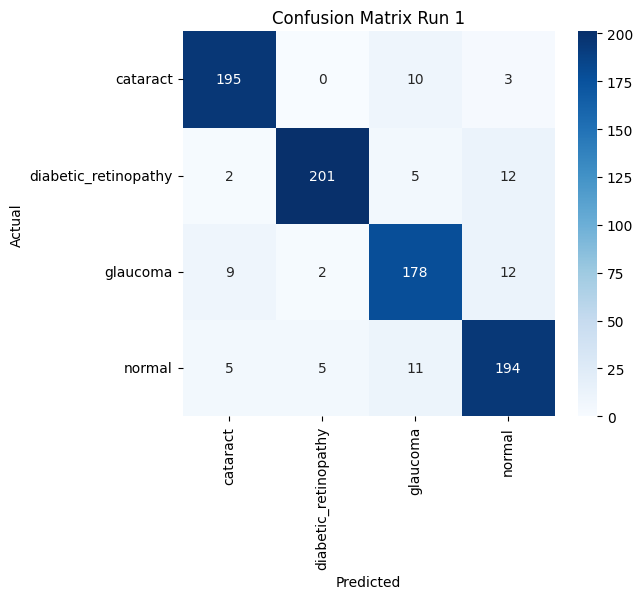


========== RUN 2 ==========

Searching best k...
k = 1 | val accuracy = 0.8673
k = 3 | val accuracy = 0.8495
k = 5 | val accuracy = 0.8389
k = 7 | val accuracy = 0.8400
k = 9 | val accuracy = 0.8436
k = 11 | val accuracy = 0.8270
Best k: 1
Test accuracy: 0.8779620853080569


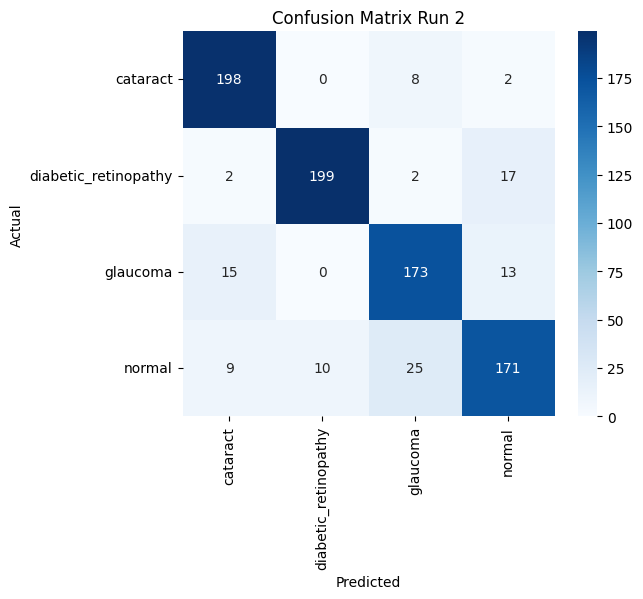


========== RUN 3 ==========

Searching best k...
k = 1 | val accuracy = 0.8637
k = 3 | val accuracy = 0.8543
k = 5 | val accuracy = 0.8543
k = 7 | val accuracy = 0.8519
k = 9 | val accuracy = 0.8507
k = 11 | val accuracy = 0.8353
Best k: 1
Test accuracy: 0.8945497630331753


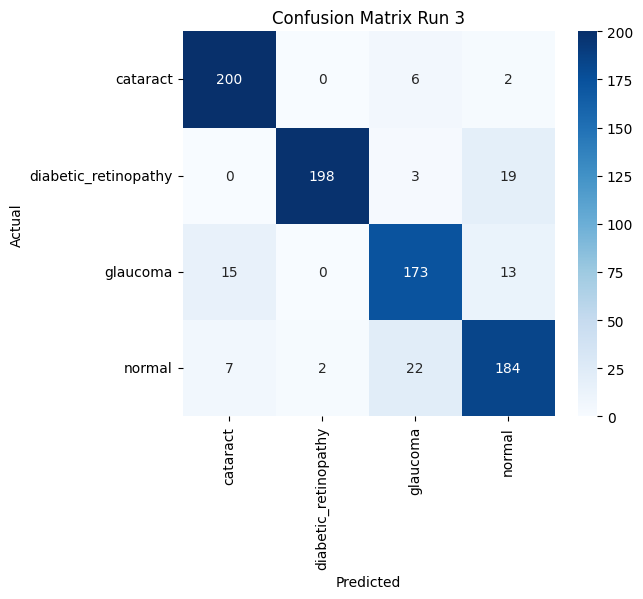


========== RUN 4 ==========

Searching best k...
k = 1 | val accuracy = 0.8697
k = 3 | val accuracy = 0.8590
k = 5 | val accuracy = 0.8400
k = 7 | val accuracy = 0.8223
k = 9 | val accuracy = 0.8104
k = 11 | val accuracy = 0.8104
Best k: 1
Test accuracy: 0.9040284360189573


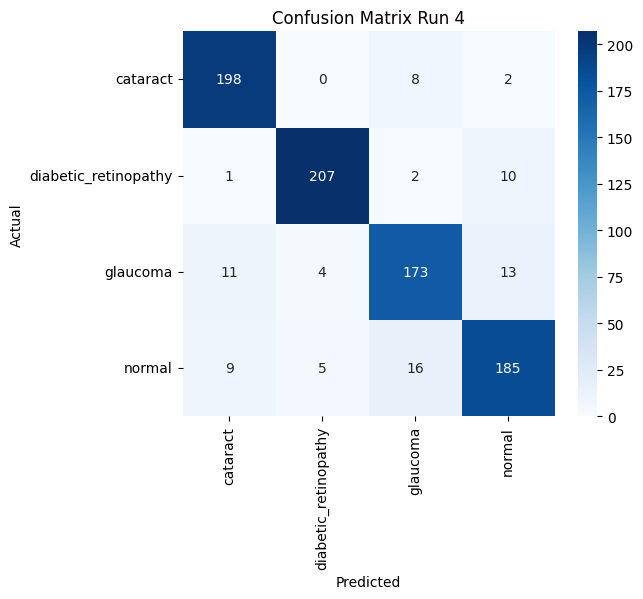


========== RUN 5 ==========

Searching best k...
k = 1 | val accuracy = 0.8661
k = 3 | val accuracy = 0.8780
k = 5 | val accuracy = 0.8697
k = 7 | val accuracy = 0.8637
k = 9 | val accuracy = 0.8602
k = 11 | val accuracy = 0.8519
Best k: 3
Test accuracy: 0.8732227488151659


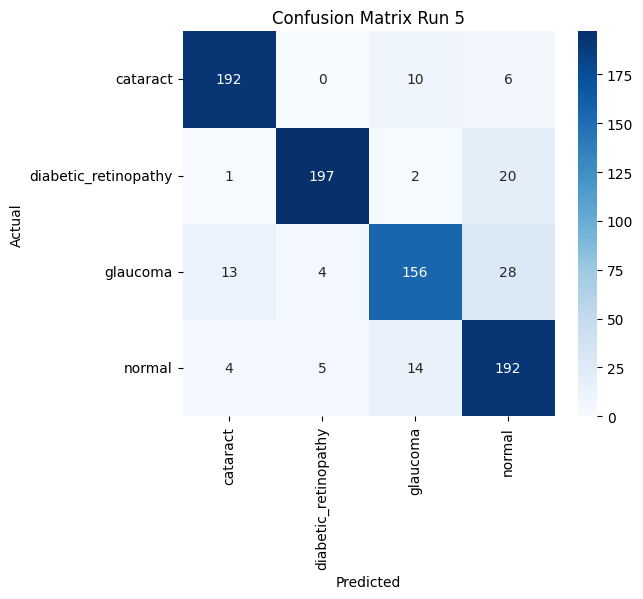


FINAL MULTI-RUN RESULT
Run 1: 0.9100
Run 2: 0.8780
Run 3: 0.8945
Run 4: 0.9040
Run 5: 0.8732

Mean Accuracy: 0.8919431279620852
Std Accuracy: 0.014304633433920895
Best Accuracy: 0.909952606635071


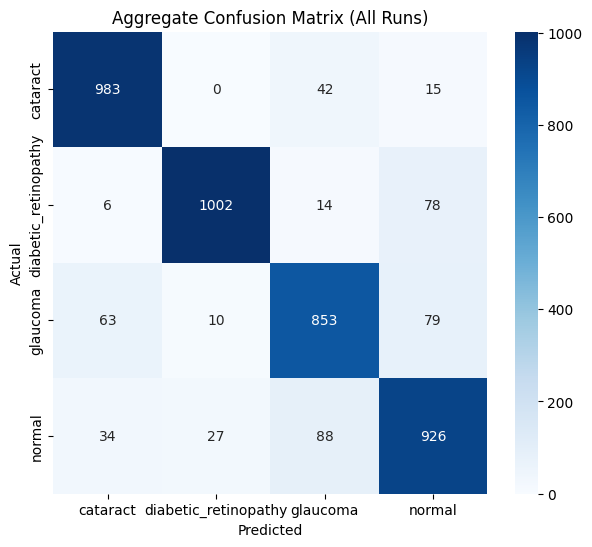


Best model saved successfully.


In [1]:
# ============================================================
# HYBRID RESNET50 + KNN
# MULTI-RUN (5x) + CONFUSION MATRIX + SAVE BEST MODEL
# ============================================================

import os
import cv2
import numpy as np
import random
import pickle

from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sb

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "dataset"
IMG_SIZE = (224, 224)
TEST_SIZE = 0.2
BATCH_SIZE = 32
RUNS = 5

K_CANDIDATES = [1,3,5,7,9,11]


# ============================================================
# LOAD DATASET
# ============================================================

print("\nLoading dataset...")

image_paths = glob(os.path.join(DATA_DIR, "*", "*"))

images = []
labels = []

for path in image_paths:

    try:

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)

        images.append(img)

        label = os.path.basename(os.path.dirname(path))
        labels.append(label)

    except Exception as e:

        print("Skip:", path, "| Error:", e)


images = np.array(images, dtype="float32")
labels = np.array(labels)

print("Total images:", len(images))
print("Classes:", np.unique(labels))


# ============================================================
# PREPROCESS INPUT
# ============================================================

images_pre = preprocess_input(images)


# ============================================================
# FEATURE EXTRACTION
# ============================================================

print("\nExtracting features using ResNet50...")

resnet_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

for layer in resnet_model.layers:
    layer.trainable = False


features = resnet_model.predict(
    images_pre,
    batch_size=BATCH_SIZE,
    verbose=1
)


# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)


# ============================================================
# MULTI-RUN EXPERIMENT
# ============================================================

results = []

all_y_test = []
all_y_pred = []

best_accuracy = 0
best_model_bundle = None


for run in range(RUNS):

    print(f"\n========== RUN {run+1} ==========")

    np.random.seed(run)
    tf.random.set_seed(run)
    random.seed(run)


    # SPLIT DATA

    X_temp, X_test, y_temp, y_test = train_test_split(
        features,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=run
    )


    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=0.25,
        stratify=y_temp,
        random_state=run
    )


    # STANDARDIZATION

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)


    # SEARCH BEST K

    best_k = None
    best_val_acc = 0


    print("\nSearching best k...")

    for k in K_CANDIDATES:

        knn_temp = KNeighborsClassifier(
            n_neighbors=k,
            metric="euclidean",
            n_jobs=-1
        )

        knn_temp.fit(X_train, y_train)

        val_acc = accuracy_score(
            y_val,
            knn_temp.predict(X_val)
        )

        print(f"k = {k} | val accuracy = {val_acc:.4f}")

        if val_acc > best_val_acc:

            best_val_acc = val_acc
            best_k = k


    print("Best k:", best_k)


    # FINAL TRAINING

    X_final = np.vstack((X_train, X_val))
    y_final = np.concatenate((y_train, y_val))


    knn_model = KNeighborsClassifier(
        n_neighbors=best_k,
        metric="euclidean",
        n_jobs=-1
    )

    knn_model.fit(X_final, y_final)


    # TEST EVALUATION

    y_pred = knn_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("Test accuracy:", acc)

    results.append(acc)


    # CONFUSION MATRIX PER RUN

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sb.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"Confusion Matrix Run {run+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


    # SAVE FOR GLOBAL MATRIX

    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)


    # SAVE BEST MODEL

    if acc > best_accuracy:

        best_accuracy = acc

        best_model_bundle = {
            "resnet_model": resnet_model,
            "knn_model": knn_model,
            "scaler": scaler,
            "label_encoder": label_encoder,
            "best_k": best_k,
            "img_size": IMG_SIZE
        }


# ============================================================
# FINAL RESULT SUMMARY
# ============================================================

mean_acc = np.mean(results)
std_acc = np.std(results)

print("\n==============================")
print("FINAL MULTI-RUN RESULT")
print("==============================")

for i, r in enumerate(results):

    print(f"Run {i+1}: {r:.4f}")

print("\nMean Accuracy:", mean_acc)
print("Std Accuracy:", std_acc)
print("Best Accuracy:", best_accuracy)


# ============================================================
# AGGREGATE CONFUSION MATRIX
# ============================================================

cm_total = confusion_matrix(all_y_test, all_y_pred)

plt.figure(figsize=(7,6))

sb.heatmap(
    cm_total,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Aggregate Confusion Matrix (All Runs)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================================
# SAVE BEST MODEL
# ============================================================

os.makedirs("models", exist_ok=True)

with open("models/hybrid_resnet50_knn_best.pkl", "wb") as f:

    pickle.dump(best_model_bundle, f)

print("\nBest model saved successfully.")